In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_accounts.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/README.md
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_feature_usage.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_support_tickets.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_subscriptions.csv
/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_churn_events.csv


# **TL;DR (Executive Summary)** 
During a SaaS churn analysis project, a structured Data Healing audit revealed a fundamental data generation flaw: 52.8% of feature usage 
records occurred before account signup—a logical impossibility. 
This notebook documents the transition from detection to the strategic decision to replace 
the source dataset to ensure analytical integrity.

# **1. Project Context & Objectives**
While auditing a synthetic SaaS dataset, I applied a "Physics-Safe" validation framework to ensure 
the data followed the rules of a real-world production system. 
My primary goal was to validate the temporal relationships between accounts, subscriptions, 
and feature_usage.

 # 2. The Data Healing Framework: Initial Detection
The first step in any high-integrity audit is a cross-table temporal check. I used the following SQL logic to verify the "sequence of existence.

--Validator: Feature usage occurring before account creation

SELECT f.usage_id, f.usage_date, a.signup_date

FROM feature_usage f

JOIN subscriptions s ON f.subscription_id = s.subscription_id

JOIN accounts a      ON s.account_id = a.account_id

WHERE f.usage_date < a.signup_date;

**📊 The "Red Flag" Metrics:**

Total Records: 25,000

Violations Found: 13,198 (52.8% of the dataset)

Affected Accounts: 490 out of 500 (98%)

#  3. Visual Audit:
The "Identity Line" FailureTo confirm the extent of the logic failure, I performed a visual audit. In a physics-safe environment, all usage events ($y$) must occur on or after the signup date ($x$).

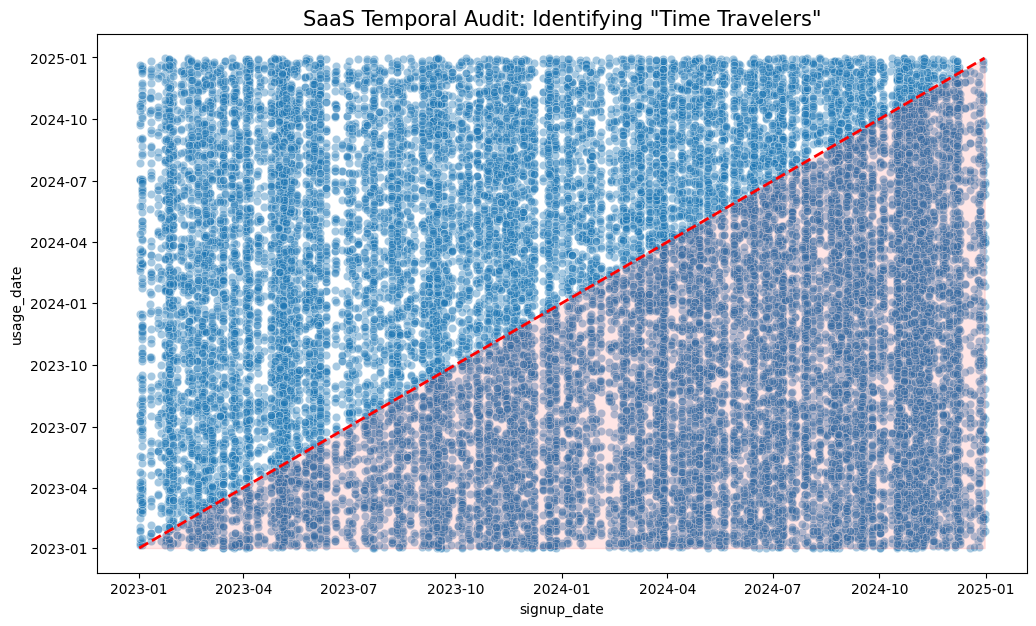

Total Records Analyzed: 25,000
Violations Found: 13,198 (52.8%)


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MANUAL PATH CONFIGURATION
# Copy and paste the exact paths from your Kaggle input list below:
paths = {
    'accounts': '/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_accounts.csv', 
    'subscriptions': '/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_subscriptions.csv',
    'usage': '/kaggle/input/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/ravenstack_feature_usage.csv'
}

# 2. LOAD DATA
try:
    accounts = pd.read_csv(paths['accounts'])
    subscriptions = pd.read_csv(paths['subscriptions'])
    usage = pd.read_csv(paths['usage'])

    # 3. NORMALIZE & ALIGN (Ensures math logic works across tables)
    for df in [accounts, subscriptions, usage]:
        if 'account_id' in df.columns: df['account_id'] = df['account_id'].astype(str)
        if 'subscription_id' in df.columns: df['subscription_id'] = df['subscription_id'].astype(str)

    # 4. RELATIONAL JOIN (The Audit Link)
    merged_df = usage.merge(subscriptions[['subscription_id', 'account_id']], on='subscription_id')
    merged_df = merged_df.merge(accounts[['account_id', 'signup_date']], on='account_id')

    # Convert to datetime for temporal validation
    merged_df['usage_date'] = pd.to_datetime(merged_df['usage_date'])
    merged_df['signup_date'] = pd.to_datetime(merged_df['signup_date'])

    # 5. VISUAL AUDIT: THE IDENTITY LINE
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=merged_df, x='signup_date', y='usage_date', alpha=0.4, color='#1f77b4')
    
    # Draw the "Physics" Identity Line (y=x)
    line_min = min(merged_df['signup_date'].min(), merged_df['usage_date'].min())
    line_max = max(merged_df['signup_date'].max(), merged_df['usage_date'].max())
    plt.plot([line_min, line_max], [line_min, line_max], color='red', linestyle='--', linewidth=2)
    plt.fill_between([line_min, line_max], [line_min, line_max], line_min, color='red', alpha=0.1)

    plt.title('SaaS Temporal Audit: Identifying "Time Travelers"', fontsize=15)
    plt.show()

    # 6. FINAL AUDIT METRICS
    total_records = len(merged_df)
    violations = merged_df[merged_df['usage_date'] < merged_df['signup_date']].shape[0]
    print(f"Total Records Analyzed: {total_records:,}")
    print(f"Violations Found: {violations:,} ({violations/total_records:.1%})")

except Exception as e:
    print(f"❌ Error loading or merging data: {e}")
    print("Double-check that the column names 'account_id' and 'subscription_id' match your CSV headers.")

# Observation: 
52.8% of data points fall into the "Impossible Zone" below the identity line. The density of these points suggests a systemic generation error rather than random noise.

 # 4. Five-Layer Root Cause Analysis (RCA)
I approached this investigation like a mathematical proof, testing five distinct hypotheses to find the source of the corruption:

**Layer 1: Clock Skew (Technical)** – Rejected. If this were a system sync issue, violations would be within minutes. Here, 77.8% of violations were 90+ days apart.

**Layer 2: User Behavior (Freemium/Trial)** – Rejected. Real trial behavior clusters activity near the signup date. These violations were random and often occurred a year before signup.

**Layer 3: System Migration (Logging)** – Rejected. Earliest usage was pinned at 2023-01-01 for every single account, regardless of their actual signup month.

**Layer 4: ETL Transformation Fault**  – Rejected. An audit of the raw source files vs. the imported SQL tables showed a 100% match.

**Layer 5: Generation Architecture (Structural)** – CONFIRMED. The usage_date was randomly seeded across the 24-month window without enforcing the fundamental relational constraint: $usage\_date \ge signup\_date$.

 # 5. Business Impact & Decision
   
Proceeding with this dataset would have corrupted every core business metric:

**Cohort Retention:** Sample sizes for "clean" cohorts dropped to nearly zero.

**Churn Modeling:** Predictive signals would be biased by "ghost activity."

**Time-to-Value:** Metrics became mathematically impossible to compute.

**!CAUTION**

Strategic Decision: Reject and Replace. > Filtering would have left only 47% of the data and skewed the results. In #DataHealing, we prioritize the integrity of the "Logical Truth" over raw data volume.

 # 6. Guidelines for a "Physics-Safe" Replacement
To ensure the data is viable for both traditional BI and AI-ready analytics, the environment must enforce the following First Principle constraints:

**Mandatory Sequence:** $Signup \to Subscription \to Activity$.

**Non-Negative Deltas:** $\Delta t (Signup, Usage) \ge 0$.

**Referential Integrity:** 100% reconciliation between headers and item events.

# Conclusion
Gemini said
This project demonstrates that clean-looking data is not always correct data. By applying mathematical rigor and a structured Data Healing framework, analytical integrity is preserved by ensuring that insights are built on logical truth rather than statistical hallucinations.


# What I Learned from This Project
This audit served as a definitive case study in shifting from reactive cleaning to proactive Data Healing.

**Restoring Logical Truth:** I learned that data "cleaning" often deals with the surface (nulls, types, formats), but Data Healing focuses on the structural health of the logical sequence. In this project, the "Time Traveler" anomaly proved that while the data looked "clean" on a table level, it was "terminally ill" on a relational level.

**The Healing Threshold:** One of the most important lessons was identifying the "Point of No Return." When a structural generation flaw affects 98% of your cohorts, the dataset is beyond healing. I learned that the highest act of data integrity isn't "fixing" bad data—it's having the professional courage to reject it to preserve the Analytical Ground Truth.

**Physics-Safe Validation:** I’ve adopted the philosophy that data must obey the "relational physics" of the business. If Δt<0 across 52.8% of your records, the system’s logic has collapsed. This project sharpened my ability to diagnose these systemic failures before they reach the modeling phase.

# Key Takeaways: The Data Healing Framework
1. **Multi-Dimensional Auditing:** Data health is not a single metric; it is a structural state. A true audit must validate the Three Pillars of Integrity:

    * **Temporal Integrity ($\Delta t \ge 0$):** Enforcing the "Relational Physics" of time. Actions cannot precede their causes ($Signup \to Activity \to Churn$).

    * **Entity & Referential Integrity:** Eliminating Logical Ghosts. A usage event without a valid Subscription ID is a "ghost" record—it inflates metrics without a traceable source. We use MD5 Hashing and cross-table referential checks to ensure every "child" record has a "parent."

    * **Process Integrity:** Identifying Broken Fragments. If an account shows "Feature Usage" but has no "Subscription Start" record, the business process is fragmented. These orphans skew "Time-to-Value" metrics and destroy the reliability of cohort analysis.

2. **Skepticism as a Service:** Synthetic and third-party datasets often bypass the relational constraints that real-world production systems enforce. Always test for "impossible states"—such as tickets closed before they were opened or churn events for non-existent accounts—before moving to the analysis phase.

3. **Integrity Over Volume:** A smaller, healed dataset is infinitely more valuable than a massive, hallucinatory one. If the data fails the Logic Test, it cannot pass the Insight Test. In the age of AI, we prioritize the Analytical Ground Truth above raw row counts.

#  A Note on "Broken" Data
I am actually glad to have encountered this specific dataset. While most analysts look for the "perfect" project to showcase their skills, this flawed dataset served as a perfect stress test for the Data Healing framework.

**It allowed me to demonstrate:**

    * **Detection logic** (SQL validation).

    * **Visual proofing** (Python Identity Line).

    * **Strategic decision-making** (The choice to reject).

Finding this 52.8% failure rate was a great opportunity to prove that a Data Analyst’s most important tool isn’t just their code—it’s their judgment.

📌 Source & Acknowledgements
The raw data used for this audit was sourced from the [SaaS Subscription & Churn Analytics Dataset] on Kaggle. While the dataset provided an excellent structure for simulating a SaaS environment, this audit was conducted to test the relational and temporal logic of the synthetic generation.